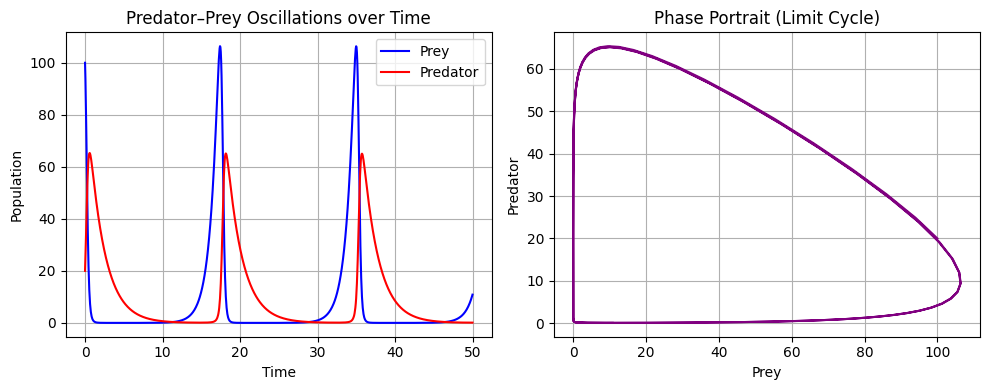

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parameters
r  = 1.0    # prey intrinsic growth rate
q  = 0.5    # predator death rate
α  = 0.1    # predation rate (prey removal per encounter)
β  = 0.05   # predator conversion efficiency

# Initial populations: [prey, predator]
X0 = 100.0
Y0 = 20.0
y0 = [X0, Y0]

# Time span
t_span = (0, 50)           # [start, end]
t_eval = np.linspace(0, 50, 1000)  # dense output for plotting

# Lotka–Volterra ODEs: dy/dt = f(t, y)
def predator_prey(t, y):
    X, Y = y
    dXdt = r*X - α*X*Y
    dYdt = β*X*Y - q*Y
    return [dXdt, dYdt]

# Solve the system
sol = solve_ivp(
    predator_prey,
    t_span,
    y0,
    t_eval=t_eval,
    method="RK45"
)

# Extract trajectories
t = sol.t
X = sol.y[0]   # prey
Y = sol.y[1]   # predator

# Plot time series
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(t, X, label="Prey", color="blue")
plt.plot(t, Y, label="Predator", color="red")
plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Predator–Prey Oscillations over Time")
plt.legend()
plt.grid(True)

# Phase plot: prey vs predator
plt.subplot(1, 2, 2)
plt.plot(X, Y, color="purple")
plt.xlabel("Prey")
plt.ylabel("Predator")
plt.title("Phase Portrait (Limit Cycle)")
plt.grid(True)

plt.tight_layout()
plt.show()